# Kernel Density Estimation for SNOWPACK Thickness Analysis under Climate Scenarios

This repository contains a Python workflow for analyzing **snowpack layer thickness changes** across different climate scenarios using station-based `.pro` output files.

The analysis compares **baseline conditions** against future climate scenarios and quantifies **changes in snowpack structure** at multiple buoy locations.

---

## Overview

The script processes snow stratigraphy data from multiple buoy stations and computes:

- Layer thickness distributions  
- Changes in thickness between **baseline** and **future scenarios**  
- Statistical properties of these changes  
- Kernel density estimates (KDE) of thickness differences  

### Climate Scenarios

- SSP126 (low emissions)  
- SSP245 (medium emissions)  
- SSP585 (high emissions)  

### Stations (Buoys)

- S114  
- S12  
- S38  
- S56  

/Users/zubairasyraf/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/zubairasyraf/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/zubairasyraf/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/zubairasyraf/anaconda3/lib/python3.11/site-packages/s

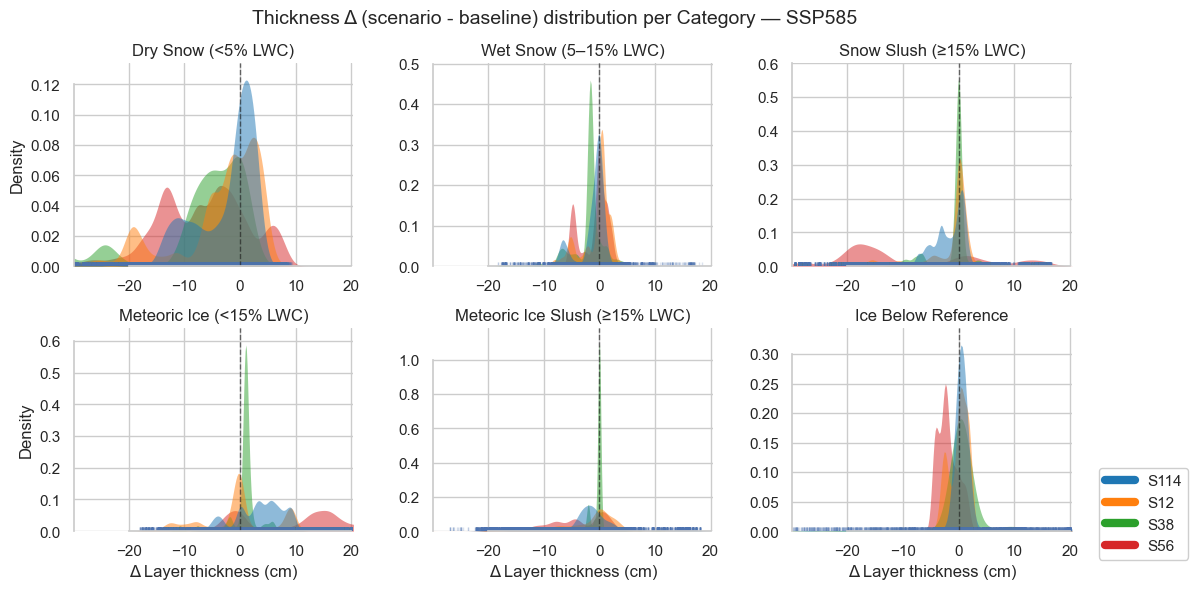

In [9]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from snowpat import snowpackreader as spr

# --------------------------- Configuration -----------------------------------
SCENARIO = "SSP585"  # change to "SSP126" or "SSP245" as needed

# Buoys of interest (order also controls legend)
BUOYS = ["S114", "S12", "S38", "S56"]

# File paths

STATION_FILES = {
    "S114_Baseline": "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",
    "S12_Baseline":  "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",
    "S38_Baseline":  "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",
    "S56_Baseline":  "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_Baseline.pro",

    "S114_SSP126":   "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",
    "S12_SSP126":    "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",
    "S38_SSP126":    "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",
    "S56_SSP126":    "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP126.pro",

    "S114_SSP245":   "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",
    "S12_SSP245":    "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",
    "S38_SSP245":    "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",
    "S56_SSP245":    "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP245.pro",

    "S114_SSP585":   "S114_S114_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
    "S12_SSP585":    "S12_S12_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
    "S38_SSP585":    "S38_S38_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
    "S56_SSP585":    "S56_S56_OHF_5_2cm_dyn_sal_1h_TAera5_NO_SSP585.pro",
}

# Category mapping (MK + LWC → category id)
def group_mk(mk: int, lwc: float, above_ref: bool = True) -> int:
    # 0–2: fresh snow
    if mk in {0, 1, 2}:
        if   lwc <  5: return 1
        elif lwc < 15: return 2
        else:           return 3

    # 11,12,21,22: meteoric-ice markers (wet/slushy)
    if mk in {11, 12, 21, 22}:
        if   lwc < 15: return 2
        else:           return 3

    # 7,8,17,18,27,28: glacier/thermodynamic/more consolidated ice
    if mk in {7, 8, 17, 18, 27, 28}:
        if above_ref:
            return 4 if lwc < 15 else 5
        else:
            return 7  # Ice below reference

    # reference markers
    if mk in {9007, 9017, 9027}:
        return 6

    return 0

CATS = [1, 2, 3, 4, 5, 7]
CAT_LABELS = {
    1: "Dry Snow (<5% LWC)",
    2: "Wet Snow (5–15% LWC)",
    3: "Snow Slush (≥15% LWC)",
    4: "Meteoric Ice (<15% LWC)",
    5: "Meteoric Ice Slush (≥15% LWC)",
    7: "Ice Below Reference"
}
REF_MARKERS = {9007, 9017, 9027}

# --------------------------- Helpers -----------------------------------------
def safe_read_pro(path: str):
    """Read a .pro file and keep layers below ground if needed."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    pro = spr.readPRO(path)
    pro.discard_below_ground(discard=False)
    return pro

def grouped_thickness_timeseries(pro_obj):
    """
    Returns dict[category] -> {timestamp: total_thickness_for_that_category}

    Categories 1–5: summed ONLY above the first reference marker.
    Category 7:     summed ONLY below (and including) the reference marker region.
    """
    dates = pro_obj.get_all_dates()
    profs = pro_obj.get_all_profiles()
    out = {c: {} for c in CATS}

    for dt, prof in zip(dates, profs):
        df = prof.toDf(CodesToName=pro_obj.DataCodes)

        mk    = df["element mk"].to_numpy()
        lwc   = df["liquid water content by volume"].to_numpy()
        thick = df["layer thickness"].to_numpy()  # keep original units

        # --- locate first reference marker ---
        ref_idx = np.where(np.isin(mk, list(REF_MARKERS)))[0]
        start = ref_idx[0] + 1 if ref_idx.size else 0

        # ABOVE reference (cats 1–5)
        mk_a, lwc_a, thick_a = mk[start:], lwc[start:], thick[start:]
        grp_a = np.array([group_mk(int(m), float(l), above_ref=True) for m, l in zip(mk_a, lwc_a)]) if mk_a.size else np.array([])

        # BELOW reference (cat 7 only)
        mk_b, lwc_b, thick_b = mk[:start], lwc[:start], thick[:start]
        grp_b = np.array([group_mk(int(m), float(l), above_ref=False) for m, l in zip(mk_b, lwc_b)]) if mk_b.size else np.array([])

        for c in CATS:
            if c == 7:
                out[c][dt] = float(np.nansum(thick_b[grp_b == 7])) if grp_b.size else 0.0
            else:
                out[c][dt] = float(np.nansum(thick_a[grp_a == c])) if grp_a.size else 0.0

    return out

def build_deltas(buoys, scenario, station_files):
    """
    For each buoy and MK category, compute Δ thickness timeseries
    (scenario − baseline) at matched timestamps. Returns:
    - delta_by_buoy_cat: dict[buoy][cat] = 1D np.array of deltas
    - long_df: long DataFrame with columns [buoy, mk, mk_label, delta_thk]
    """
    delta_by_buoy_cat = {b: {c: np.array([]) for c in CATS} for b in buoys}

    for b in buoys:
        base_key = f"{b}_Baseline"
        scen_key = f"{b}_{scenario}"
        if base_key not in station_files or scen_key not in station_files:
            print(f"[WARN] Missing mapping for {b} in Baseline or {scenario}. Skipping.")
            continue

        base = safe_read_pro(station_files[base_key])
        scen = safe_read_pro(station_files[scen_key])

        base_g = grouped_thickness_timeseries(base)
        scen_g = grouped_thickness_timeseries(scen)

        for c in CATS:
            common_t = sorted(set(base_g[c]).intersection(scen_g[c]))
            if not common_t:
                continue
            delta = np.array([scen_g[c][t] - base_g[c][t] for t in common_t], dtype=float)
            delta = delta[np.isfinite(delta)]
            if delta.size:
                delta_by_buoy_cat[b][c] = delta

    # Long-form dataframe for plotting
    rows = []
    for buoy, bycat in delta_by_buoy_cat.items():
        for c, arr in bycat.items():
            if arr.size:
                rows.extend(
                    {"buoy": buoy, "mk": c, "mk_label": CAT_LABELS[c], "delta_thk": v}
                    for v in arr
                )
    long_df = pd.DataFrame(rows)
    return delta_by_buoy_cat, long_df

def plot_kde(long_df, scenario, buoys):
    """Facet KDEs per category, hue by buoy, with shared x-range and clean legend."""
    if long_df.empty:
        print("[INFO] No data to plot.")
        return

    # Shared x-limits from pooled 1–99% to avoid long tails
    q1, q2 = np.quantile(long_df["delta_thk"], [0.01, 0.99])
    pad = 0.05 * (q2 - q1)
    xlim_shared = (q1 - pad, q2 + pad)

    sns.set_theme(style="whitegrid")
    buoy_order = [b for b in buoys if b in long_df["buoy"].unique()]
    palette = dict(zip(buoy_order, sns.color_palette("tab10", n_colors=len(buoy_order))))

    g = sns.FacetGrid(
        long_df, col="mk_label", col_wrap=3, sharex=False, sharey=False,
        height=3.0, aspect=1.25
    )

    kde_kwargs = dict(
        x="delta_thk", hue="buoy",
        fill=True, common_norm=False, bw_adjust=1.0,
        alpha=0.5, linewidth=0, palette=palette, clip=xlim_shared
    )
    g.map_dataframe(sns.kdeplot, **kde_kwargs)
    g.map_dataframe(sns.rugplot, x="delta_thk", height=0.02, alpha=0.2)

    for ax in g.axes.flat:
        ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_xlim(xlim_shared)

    g.set_axis_labels("Δ Layer thickness (cm)", "Density")
    g.set_titles("{col_name}")
    sns.despine(trim=True)

    # Unified legend
    handles = [Line2D([0], [0], lw=6, color=palette[b]) for b in buoy_order]
    g.fig.legend(
        handles, buoy_order,
        loc="lower right", bbox_to_anchor=(1.07, 0.02),
        ncol=1, frameon=True, fancybox=True, framealpha=0.95,
        borderaxespad=0.5
    )

    g.fig.subplots_adjust(bottom=0.08, right=0.96, top=0.86)
    g.fig.suptitle(
        f"Thickness Δ (scenario - baseline) distribution per Category — {scenario}",
        y=0.95, fontsize=14
    )
    plt.show()

def print_stats_table(delta_by_buoy_cat):
    """
    Print a table of Median, IQR, P(Δ>0), P5, P95, N per (buoy × category).
    """
    rows = []
    for buoy, bycat in delta_by_buoy_cat.items():
        for c, arr in bycat.items():
            arr = np.asarray(arr, dtype=float)
            if arr.size == 0:
                continue
            med = np.nanmedian(arr)
            q1, q3 = np.nanpercentile(arr, [25, 75])
            iqr = q3 - q1
            p5, p95 = np.nanpercentile(arr, [5, 95])
            ppos = float(np.mean(arr > 0))  # share of strictly positive deltas
            n = int(np.sum(np.isfinite(arr)))
            rows.append({
                "MK": c,
                "MK label": CAT_LABELS[c],
                "Buoy": buoy,
                "N": n,
                "Median Δ": med,
                "IQR": iqr,
                "P(Δ>0)": ppos,
                "P5": p5,
                "P95": p95,
            })

    df_stats = pd.DataFrame(rows)
    if df_stats.empty:
        print("[INFO] No statistics to print (no deltas).")
        return df_stats

    # Nice ordering by MK then buoy
    cat_order = {c: i for i, c in enumerate(CATS)}
    df_stats["MK_order"] = df_stats["MK"].map(cat_order)
    df_stats = df_stats.sort_values(["MK_order", "Buoy"]).drop(columns="MK_order")

    # Print neatly
    print(df_stats.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    return df_stats

# --------------------------- Main --------------------------------------------
def main():
    try:
        delta_by_buoy_cat, long_df = build_deltas(BUOYS, SCENARIO, STATION_FILES)
    except FileNotFoundError as e:
        print(f"[ERROR] {e}")
        return

    plot_kde(long_df, SCENARIO, BUOYS)
    # _ = print_stats_table(delta_by_buoy_cat)

if __name__ == "__main__":
    main()